# 01 - Data Preparation

Este notebook realiza la carga, normalización y preparación de datos para el entrenamiento de modelos.

## 1. Importar librerías

In [1]:
import sys
import os

# Añadir src a path para importar utils
# sys.path.append(os.path.join(os.getcwd(), '../../src'))
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from src.utils import (
    load_and_prepare_data,
    save_data_npz,
    TRAIN_PATH,
    TEST_PATH,
    DATA_NPZ_PATH,
    CATEGORIES
)

## 2. Cargar datos

In [2]:
# Cargar y preparar datos de train y test
print('Cargando datos...')
X_train, X_test, y_train, y_test = load_and_prepare_data(grayscale=False, random_state=42)

print(f'\nShapes:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  y_train: {y_train.shape}')
print(f'  y_test:  {y_test.shape}')

Cargando datos...
Cargando datos de train...
Cargando datos de test...
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/sin-cara\sin-cara_002.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/sin-cara\sin-cara_005.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/sin-cara\sin-cara_008.png


c:\Users\NitroPC\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_008.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_009.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_010.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_011.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_012.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_013.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_014.png
Shape inesperado (224, 224, 4) → c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/test/cara\cara_015.png
Shape inesperado

## 3. Verificar normalización

In [3]:
print(f'Rango de valores en X_train:')
print(f'  Min: {X_train.min():.4f}')
print(f'  Max: {X_train.max():.4f}')
print(f'\nRango de valores en X_test:')
print(f'  Min: {X_test.min():.4f}')
print(f'  Max: {X_test.max():.4f}')

Rango de valores en X_train:
  Min: 0.0000
  Max: 1.0000

Rango de valores en X_test:
  Min: 0.0000
  Max: 1.0000


## 4. Visualizar ejemplos

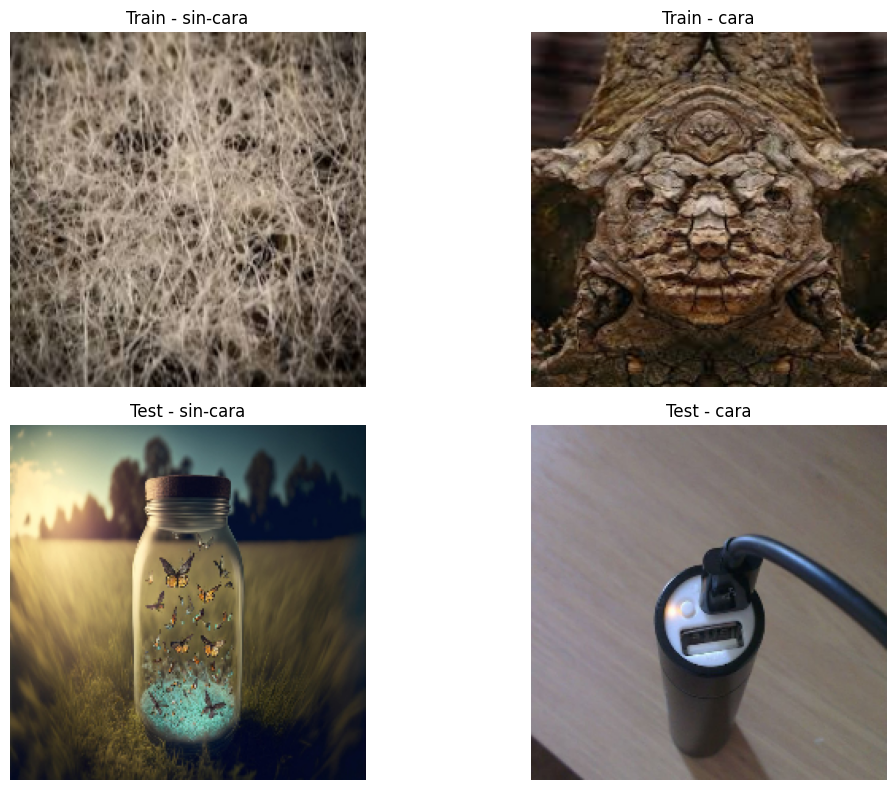

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, cat_idx in enumerate(CATEGORIES):
    # Encontrar índices de cada categoría
    indices = np.where(y_train == i)[0]
    
    # Mostrar en train
    ax = axes[0, i]
    sample_idx = indices[0]
    ax.imshow(X_train[sample_idx])
    ax.set_title(f'Train - {cat_idx}')
    ax.axis('off')
    
    # Mostrar en test
    ax = axes[1, i]
    indices_test = np.where(y_test == i)[0]
    if len(indices_test) > 0:
        ax.imshow(X_test[indices_test[0]])
        ax.set_title(f'Test - {cat_idx}')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Distribuición de clases

In [5]:
print('Distribución en TRAIN:')
for i, cat in enumerate(CATEGORIES):
    count = (y_train == i).sum()
    pct = 100 * count / len(y_train)
    print(f'  {cat}: {count} ({pct:.1f}%)')

print('\nDistribución en TEST:')
for i, cat in enumerate(CATEGORIES):
    count = (y_test == i).sum()
    pct = 100 * count / len(y_test)
    print(f'  {cat}: {count} ({pct:.1f}%)')

Distribución en TRAIN:
  sin-cara: 557 (63.4%)
  cara: 321 (36.6%)

Distribución en TEST:
  sin-cara: 92 (52.0%)
  cara: 85 (48.0%)


## 6. Guardar datos en .npz

In [6]:
# Guardar en formato .npz para carga rápida
save_data_npz(X_train, X_test, y_train, y_test, DATA_NPZ_PATH)

Datos guardados en c:\Users\NitroPC\OneDrive\Documentos\GIT\Ants_trajectories_ML\data/data.npz
